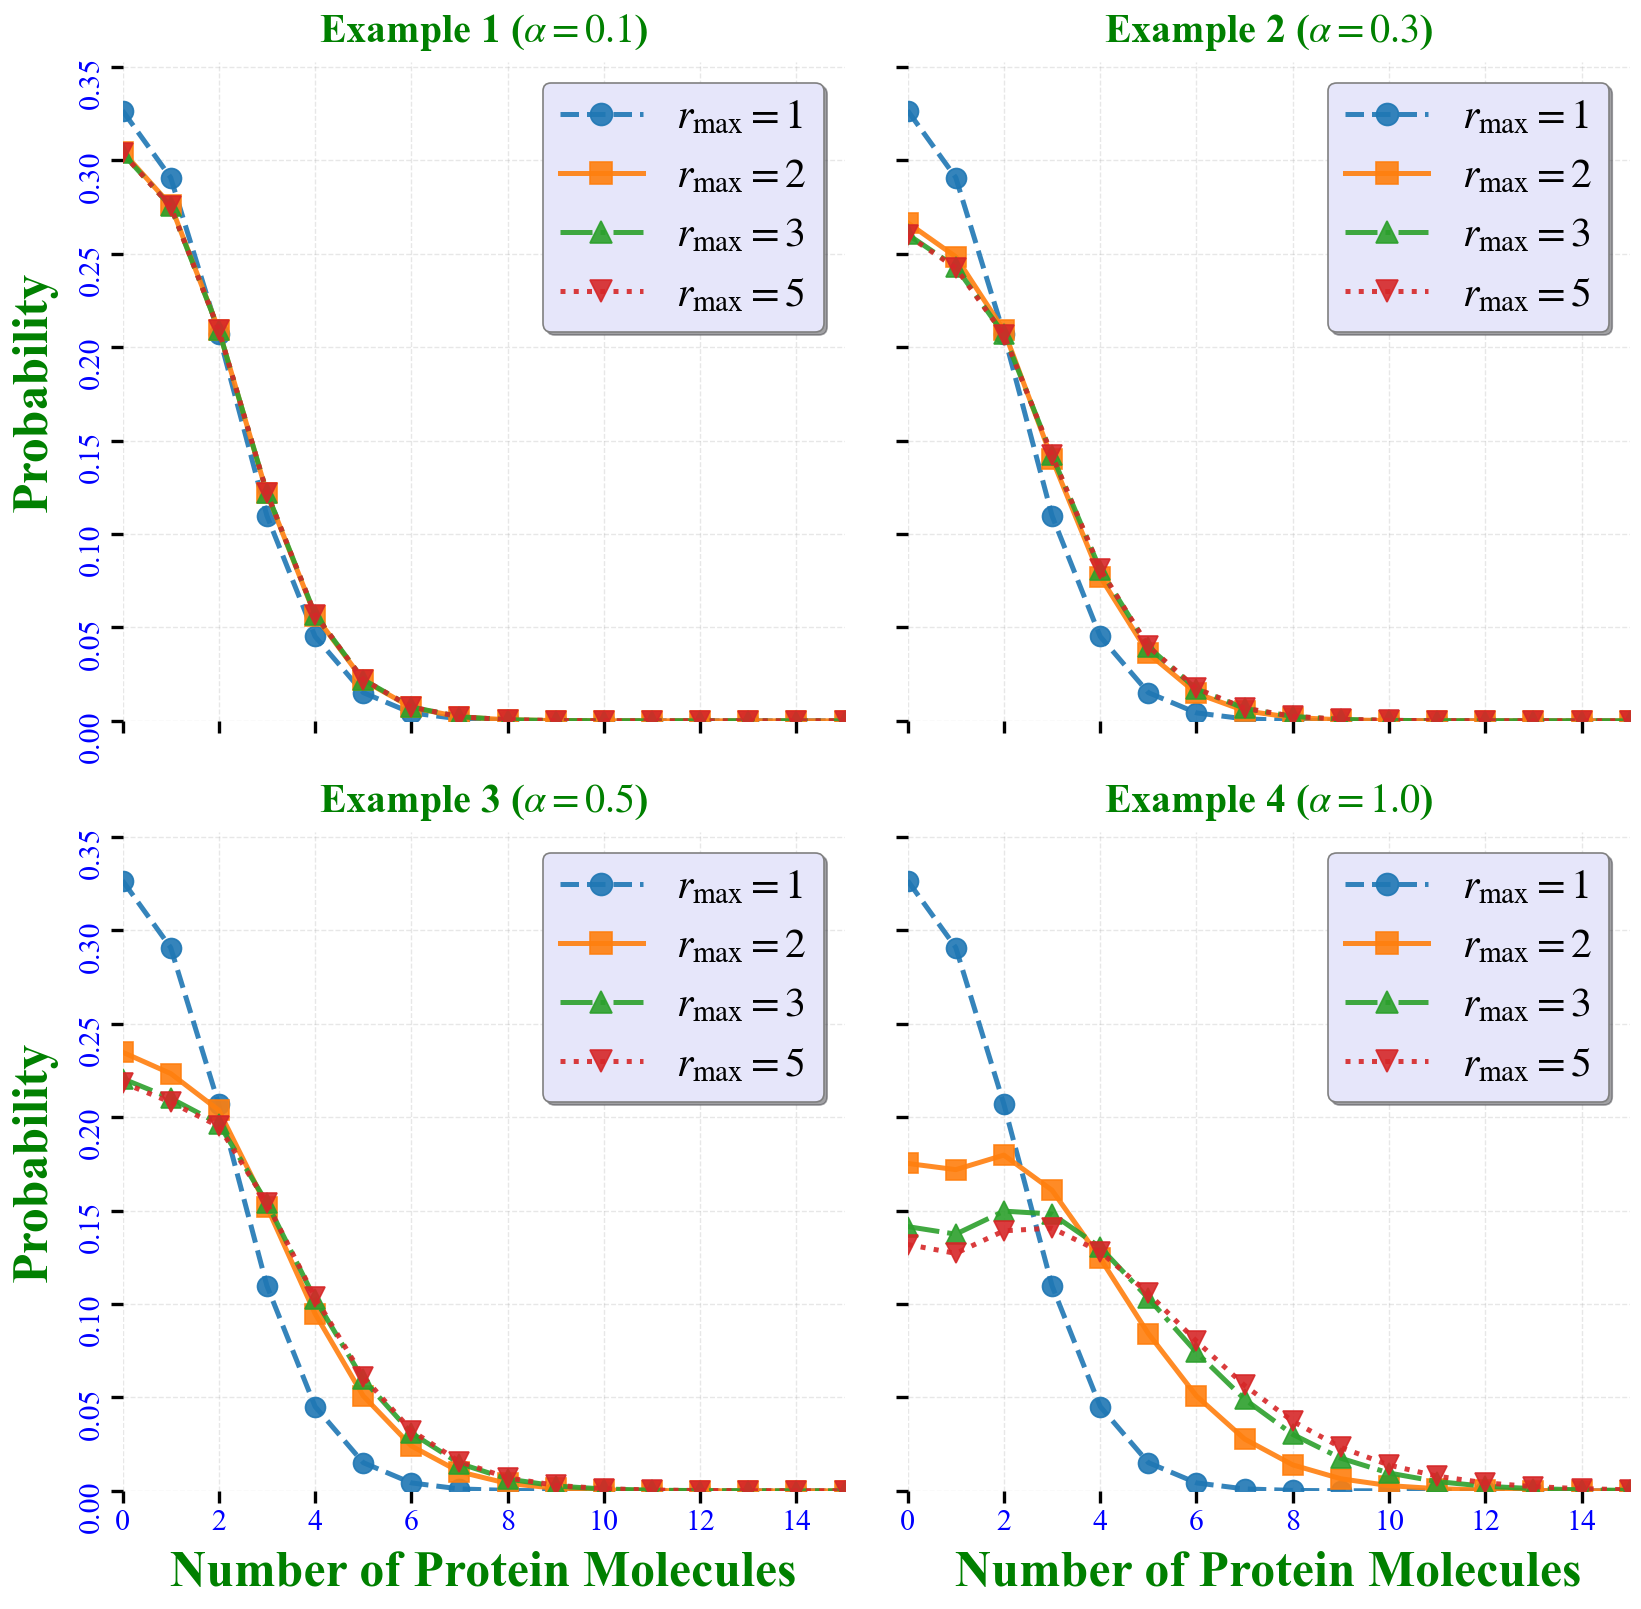

In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["axes.linewidth"] = 2
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

output_dir = Path("fig3_data")
output_dir.mkdir(parents=True, exist_ok=True)

R_max_list = [1, 2, 3, 5]
alpha_list = [0.1, 0.3, 0.5, 1.0]

alpha_plot_list = alpha_list[:4]
x_max_list = [21, 21, 21, 21]

style_map = {
    1: dict(linestyle="--", marker="o"),
    2: dict(linestyle="-", marker="s"),
    3: dict(linestyle="-.", marker="^"),
    5: dict(linestyle=":", marker="v"),
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 14),
    dpi=120,
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for idx, alpha in enumerate(alpha_plot_list):
    ax = axes[idx]
    x_max = x_max_list[idx]

    y_max_local = 0.0
    n_global = 0

    for R_max in R_max_list:
        data_path = output_dir / f"PMF_R{R_max}_alpha{alpha:.2f}.npy"

        prob = np.load(
            data_path,
            allow_pickle=True
        ).flatten()

        prob = np.asarray(prob, dtype=float)

        n = min(x_max, len(prob))
        x = np.arange(n)
        y = prob[:n]

        n_global = max(n_global, n)

        if n > 0:
            y_max_local = max(
                y_max_local,
                float(np.nanmax(y))
            )

        ax.plot(
            x,
            y,
            linewidth=3,
            markersize=12,
            alpha=0.9,
            label=rf"$r_{{\max}}={R_max}$",
            **style_map[R_max]
        )

    ax.set_xlim(0, max(n_global - 1, 1))
    ax.set_ylim(
        0,
        1.08 * y_max_local
        if y_max_local > 0
        else 1
    )

    ax.set_title(
        rf"Example {idx + 1} ($\alpha = {alpha}$)",
        fontsize=24,
        fontweight="bold",
        color="green",
        pad=12
    )

    row = idx // 2
    col = idx % 2

    if col == 0:
        ax.set_ylabel(
            "Probability",
            fontsize=30,
            fontweight="bold",
            color="green",
            labelpad=12
        )

    if row == 1:
        ax.set_xlabel(
            "Number of Protein Molecules",
            fontsize=30,
            fontweight="bold",
            color="green",
            labelpad=10
        )

    ax.tick_params(
        direction="out",
        width=2,
        length=7,
        labelsize=18
    )

    for label in ax.get_xticklabels():
        label.set_fontname("Times New Roman")
        label.set_color("blue")

    for label in ax.get_yticklabels():
        label.set_fontname("Times New Roman")
        label.set_color("blue")
        label.set_rotation(90)

    ax.grid(
        True,
        linestyle="--",
        alpha=0.3
    )

    legend = ax.legend(
        loc="upper right",
        frameon=True,
        fancybox=True,
        shadow=True,
        markerscale=1.1,
        prop={
            "family": "Times New Roman",
            "size": 25
        }
    )

    legend.get_frame().set_edgecolor("gray")
    legend.get_frame().set_facecolor("#E6E6FA")
    legend.get_frame().set_alpha(1)

    for spine in ax.spines.values():
        spine.set_visible(False)

# fig.suptitle(
#     r"Steady-State Distribution with Different Truncation Levels $r_{\max}$",
#     fontsize=28,
#     fontweight="bold",
#     color="green",
#     y=0.98
# )

plt.tight_layout(rect=[0, 0, 1, 0.965])

figure_path = ("Fig3.pdf"
)

plt.savefig(
    figure_path,
    format="pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()